# Overview
Here, we will perform the first step when creating machine learning, exporatory data analysis. We
will analyze many different attributes and verify their relationship with the classicification of an
email (is it spam?).

## Setup

In [212]:
# use this cell to install all requirements for this project.
# !pip install -r requirements.txt

In [213]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Our data follows the following format:

column         | dtype  | desciption
---------------|--------|---------------------------------------------------
filename       | str    | filename of the given file
from           | str    | domain of email sender
to             | str    | domain of email recipient
return_path    | str    | domain of the return email
message_id     | str    | domain of the 'Message-Id' header
recieved       | int    | number of entries in the 'Recieved' header
deliver_to     | int    | number of entries in the 'Deliver-To' header
weekday        | str    | day of week - (mon, tue, wed, etc.)
day            | str    | DD
month          | str    | MMM
year           | int    | YYYY
timezone       | str    | timezone of datetime, in UTC offset format
subject        | object | array of words within the subject, stemmed
body           | object | array of words within the body, stemmed


In [214]:
# import data
df = pd.read_csv('data/processed_emails.csv', index_col='filename')
df

,body,from,weekday,day,month,year,hour,timezone,to,subject,return_path,received,delivered_to,message_id,spam
filename,,,,,,,,,,,,,,,
01128.efb36914ecb55d78a894591eff0843c5,"['on', 'sun', 'NUMBER', 'jul', 'NUMBER', 'NUMB...",uni.de,sun,21,jul,2002,20,-400.0,freshrpms.net,"['re', 'ximian', 'apt', 'repo']",freshrpms.net,7,1,uni.de,False
00659.02e6dd777f837798533eae8f3b6a0491,"['what', 'is', 'mime', 'mime', 'stand', 'for',...",docserver.cac.washington.edu,mon,19,aug,2002,23,-700.0,example.sourceforge.net,"['wm', 'the', 'mime', 'inform', 'you', 'reques...",example.sourceforge.net,6,1,docserver.cac.washington.edu,False
00776.7df92458e9cf04b8873c406bde7d2fbe,"['im', 'not', 'up', 'to', 'fork', 'the', 'text...",golux.com,tue,13,aug,2002,15,-400.0,xent.com,"['a', 'messag', 'for', 'our', 'time']",xent.com,6,2,golux.com,False
00116.409b29c26edef06268b4bfa03ef1367a,"['on', 'sat', 'jul', 'NUMBER', 'NUMBER', 'at',...",skynet.ie,sat,20,jul,2002,13,100.0,linux.ie,"['re', 'ilug', 'vanquish', 'the', 'daemon', 'o...",linux.ie,8,1,skynet.ie,False
00615.23556d88fcb1179b25083cfc41017f42,"['origin', 'messag', 'date', 'thu', 'NUMBER', ...",dmv.com,thu,8,aug,2002,16,-400.0,example.sourceforge.net,"['re', 'razorus', 'use', 'razor', 'with', 'non...",example.sourceforge.net,7,1,landshark,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01311.43bfe86df65d53c5f7ca2365dc12582b,"['ffffffa9', 'copyright', 'NUMBER', 'all', 'ri...",bol.com.br,mon,05,aug,2002,21,-1700.0,dogma.slashnull.org,"['best', 'rate', 'on', 'mortgag', 'in', 'the',...",bol.com.br,4,1,mail.sunwaytech.com.cn,True
00851.dc5452f80ba0bb8481dfc48f70380c4d,"['creditfix', 'thank', 'you', 'your', 'email',...",msn.com,sun,21,jul,2002,10,-1700.0,netnv.net,"['fix', 'your', 'credit', 'yourself', 'onlin',...",msn.com,6,1,smtp-gw-4.msn.com,True
01328.b23902de23cb3ca1f3334517282372b2,"['hello', 'are', 'you', 'satisfi', 'with', 'yo...",yahoo.com,wed,07,aug,0102,16,1000.0,spamassassin.taint.org,"['new', 'internet', 'servic', 'provid']",xent.com,10,2,ccitih,True


## Exploratory Data Analysis
First, we will look through the DataFrame, search for any interesting statistics or correlated
attributes. To achieve this, we will look at various statistics and visualize/plot different 
attributes against each other.

On an initial look, features like delivered_to, recieved, and all date related features may give 
some correlation to spam.

In [215]:
# dataframe search
df.info()

<class 'pandas.DataFrame'>
Index: 3046 entries, 01128.efb36914ecb55d78a894591eff0843c5 to 00788.b98a23c07d59156d172683fc29b80661
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   body          3046 non-null   str    
 1   from          3045 non-null   str    
 2   weekday       3046 non-null   str    
 3   day           3046 non-null   str    
 4   month         3046 non-null   str    
 5   year          3046 non-null   str    
 6   hour          3046 non-null   int64  
 7   timezone      2900 non-null   float64
 8   to            2989 non-null   str    
 9   subject       3040 non-null   str    
 10  return_path   2829 non-null   str    
 11  received      3046 non-null   int64  
 12  delivered_to  3046 non-null   int64  
 13  message_id    2721 non-null   str    
 14  spam          3046 non-null   bool   
dtypes: bool(1), float64(1), int64(3), str(10)
memory usage: 359.9+ KB


In [216]:
# it appears our day and weekday values were interpreted as strings...  lets look furthur
df.day.value_counts()

day
19     177
24     176
21     173
22     156
23     141
25     128
20     123
31     112
13      99
17      88
30      88
12      86
26      85
18      84
11      75
16      75
28      74
2       73
29      67
9       65
27      65
8       63
6       58
15      58
14      57
3       52
10      52
5       50
1       46
7       45
4       41
05      40
06      39
09      37
04      35
02      35
01      34
03      34
08      29
07      29
May      2
Name: count, dtype: int64

In [217]:
# there are two emails where May is being held within the day field. lets drop these data points
df = df[df.day != 'May']

In [218]:
# alter certain types to numeric
df = df.astype({
    'body': 'object',
    'subject': 'object',
    'day' : 'int64',
    'weekday': 'category',
    'month': 'category',
    'year': 'int64',
    'timezone': 'category'
})

df.info()

<class 'pandas.DataFrame'>
Index: 3044 entries, 01128.efb36914ecb55d78a894591eff0843c5 to 00788.b98a23c07d59156d172683fc29b80661
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   body          3044 non-null   object  
 1   from          3043 non-null   str     
 2   weekday       3044 non-null   category
 3   day           3044 non-null   int64   
 4   month         3044 non-null   category
 5   year          3044 non-null   int64   
 6   hour          3044 non-null   int64   
 7   timezone      2898 non-null   category
 8   to            2987 non-null   str     
 9   subject       3038 non-null   object  
 10  return_path   2827 non-null   str     
 11  received      3044 non-null   int64   
 12  delivered_to  3044 non-null   int64   
 13  message_id    2719 non-null   str     
 14  spam          3044 non-null   bool    
dtypes: bool(1), category(3), int64(5), object(2), str(4)
memory usage: 297.7+ KB


In [219]:
# as a sanity check, lets check other fields
df.weekday.value_counts(), df.month.value_counts(), df.timezone.value_counts()

(weekday
 wed    553
 tue    526
 mon    476
 fri    460
 thu    445
 sun    307
 sat    277
 Name: count, dtype: int64,
 month
 jul    1293
 aug    1075
 may     338
 jun     190
 nov      30
 sep      27
 apr      21
 dec      19
 mar      18
 feb      17
 oct      12
 jan       4
 Name: count, dtype: int64,
 timezone
  100.0     596
 -400.0     592
 -700.0     528
 -500.0     286
  200.0     173
  0.0       117
 -1900.0    114
 -1600.0    105
  800.0      90
 -600.0      43
 -800.0      34
  530.0      28
 -1700.0     24
  300.0      24
  900.0      19
 -300.0      18
  1000.0     15
 -1800.0     13
  1200.0     13
  700.0      10
 -1000.0      7
 -900.0       7
 -1100.0      5
 -200.0       5
 -100.0       5
  500.0       5
  600.0       5
 -2200.0      4
 -1200.0      4
  400.0       4
  1100.0      4
 -2000.0      1
 Name: count, dtype: int64)

In [220]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
body,3044,2815,"['dear', 'homeown', 'NUMBER', 'NUMBER', 'yr', ...",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
from,3043,951,hotmail.com,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday,3044,7,wed,553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,3044.0,NaN,NaN,NaN,16.836071,8.685304,1.0,9.0,19.0,24.0,31.0
month,3044,12,jul,1293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,3044.0,NaN,NaN,NaN,1958.162286,287.47359,1.0,2002.0,2002.0,2002.0,2020.0
hour,3044.0,NaN,NaN,NaN,12.377464,6.390905,0.0,8.0,13.0,17.0,23.0
timezone,2898.0,32.0,100.0,596.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,2987,506,spamassassin.taint.org,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,3038,2109,"['re', 'ilug', 'suse', 'NUMBER', 'disk', 'thre...",34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [221]:
# there is also some instances where year is or 1 or 0, lets drop these as well
df = df[df.year >= 1970]

### Numerical EDA
Among our numerical values, we have many discrete features which can be plotted with spam for
greater understanding:
- Recieved
- Delivered-To
- Year (we will look to analyze, in practice the year would not be relevant in a spam classifier
which detects spam in current emails)
- Day
- Hour


In [222]:
def plot_discrete(x_var, ttl):
    _, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    sns.boxplot(data=df, x=x_var, hue='spam', showfliers=True, ax=axes[0,0])
    axes[0,0].set(title=ttl + ' vs. Spam', xlabel=ttl, ylabel='Spam')

    sns.histplot(
        data=df, x=x_var, ax=axes[0,1], hue='spam',
        discrete=True, color='#ff7f0e', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[0,1].set(title=ttl + ' Distribution', xlabel=ttl, ylabel='Density')

    sns.histplot(
        data=df[df.spam == False], x=x_var, ax=axes[1,0], 
        discrete=True, color='#1f77b4', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[1,0].set(title=ttl + ' Distribution (Ham)', xlabel=ttl, ylabel='Density')

    sns.histplot(
        data=df[df.spam == True], x=x_var, ax=axes[1,1], 
        discrete=True, color='#ff7f0e', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[1,1].set(title=ttl + ' Distribution (Spam)', xlabel=ttl, ylabel='Density')

    plt.show()

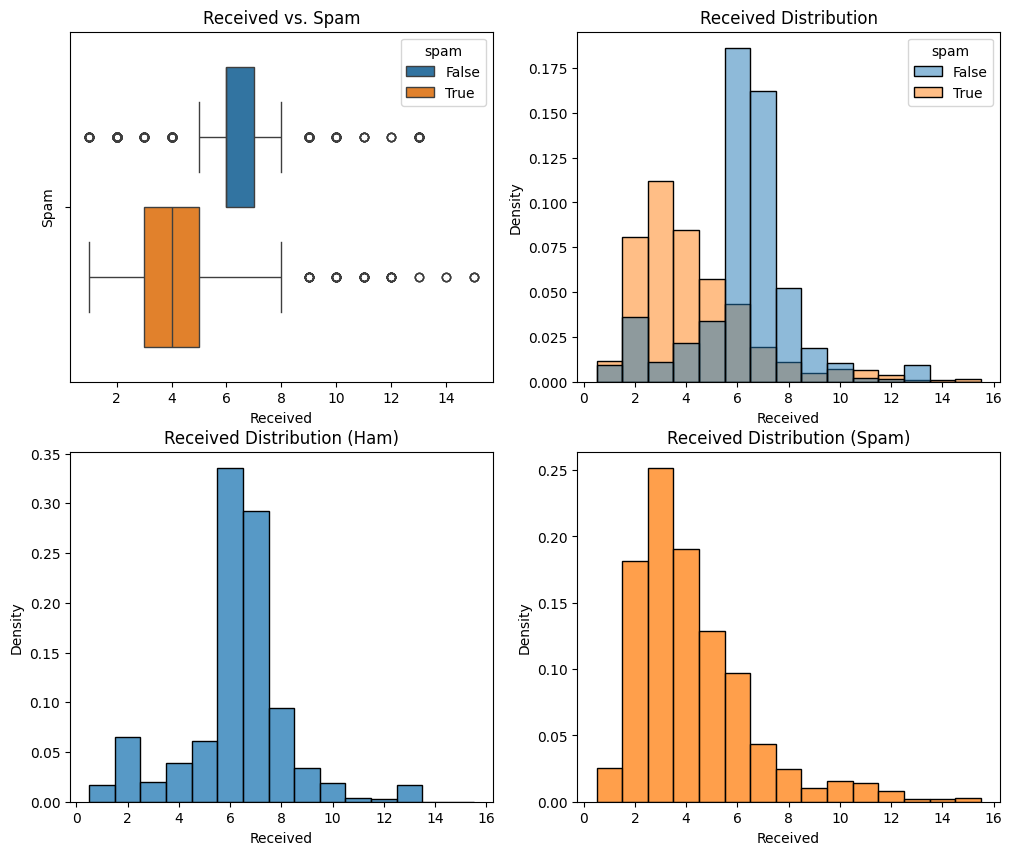

In [223]:
# a colored box plot would sufficiently show the distributions between recieved on spam or ham
plot_discrete('received', 'Received')

It is apparent that an the amount of entries in the Recieved header of an email is typically shorter
when it is spam, as opposed to ham.

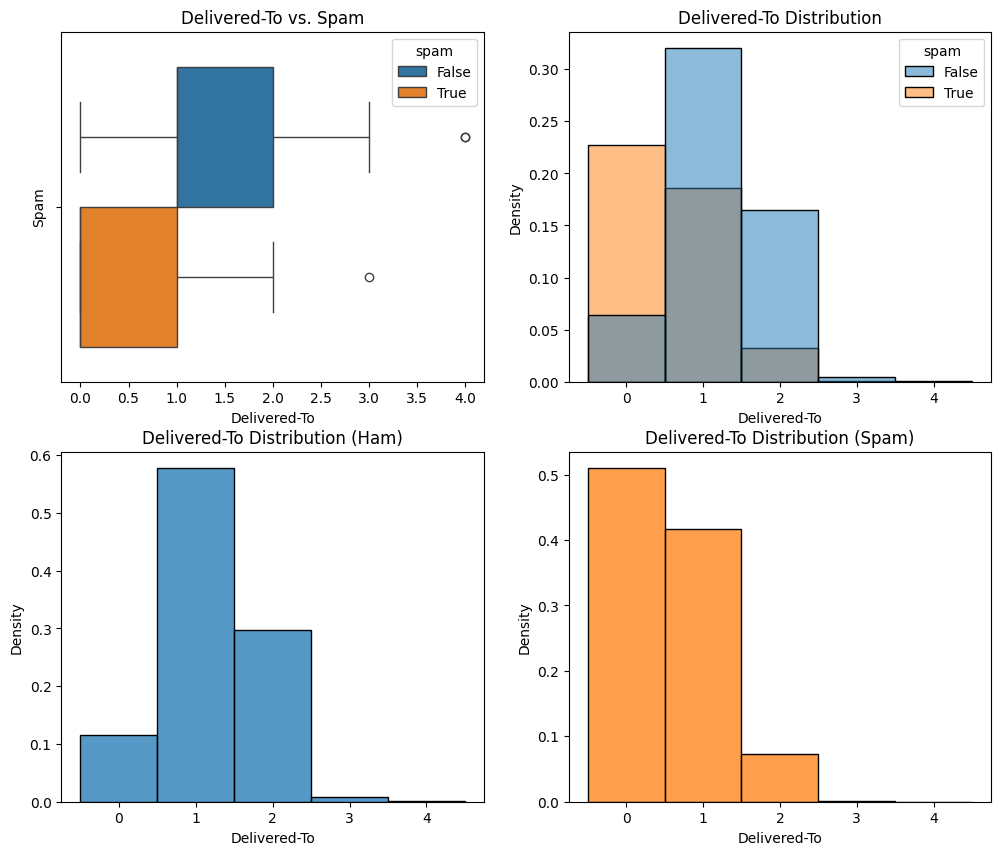

In [224]:
# Delivered-To
plot_discrete('delivered_to', 'Delivered-To')

It is apparent that an the amount of entries in the Delivered-To header of an email is typically shorter
when it is spam, as opposed to ham.

We can perform some feature engineering here. Typically, the Received and Delivered-To headers are
coupled together, as they correspond to the path an email had taken to reach a user. As such, we can
combine the two counts of entries to a new feature, titled `path_length`.

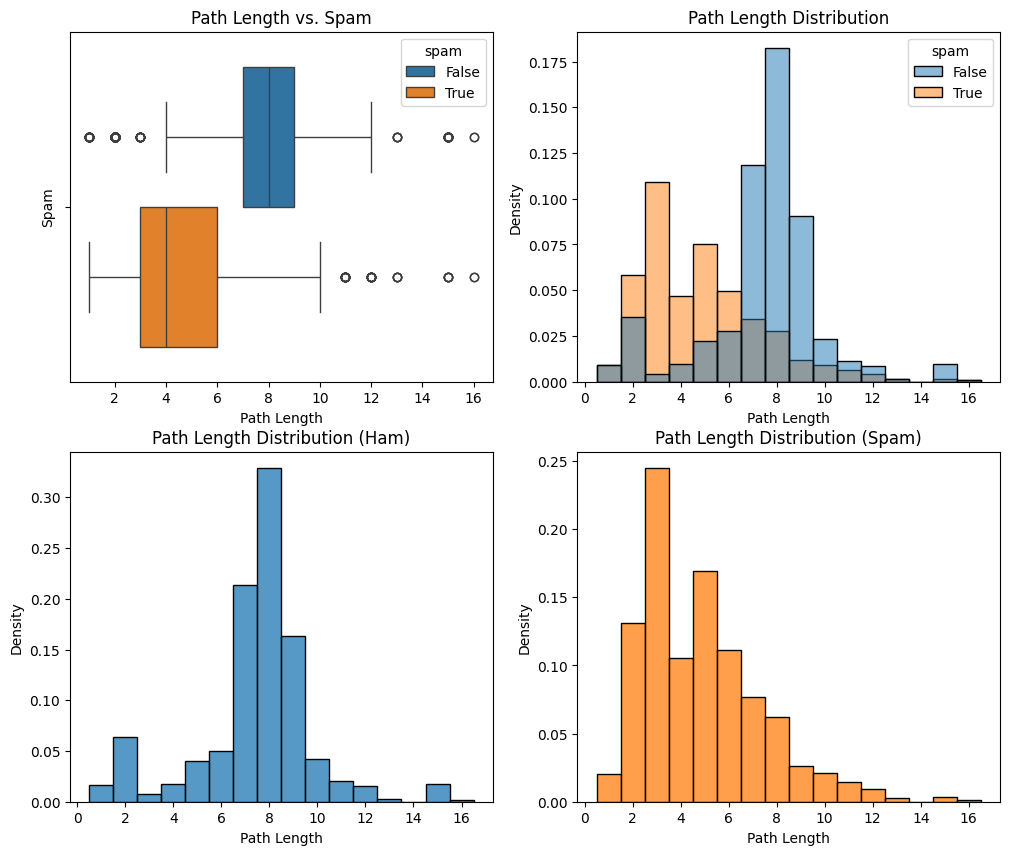

In [227]:
df['path_length'] = df.received + df.delivered_to
# we can now plot this
plot_discrete('path_length', 'Path Length')

Supporting our previous awknowledgements, the path length is found to typically be shorter in spam 
emails. It also appears that the path is much more skewed in spam, as opposed to ham with its
normally distributed path length.

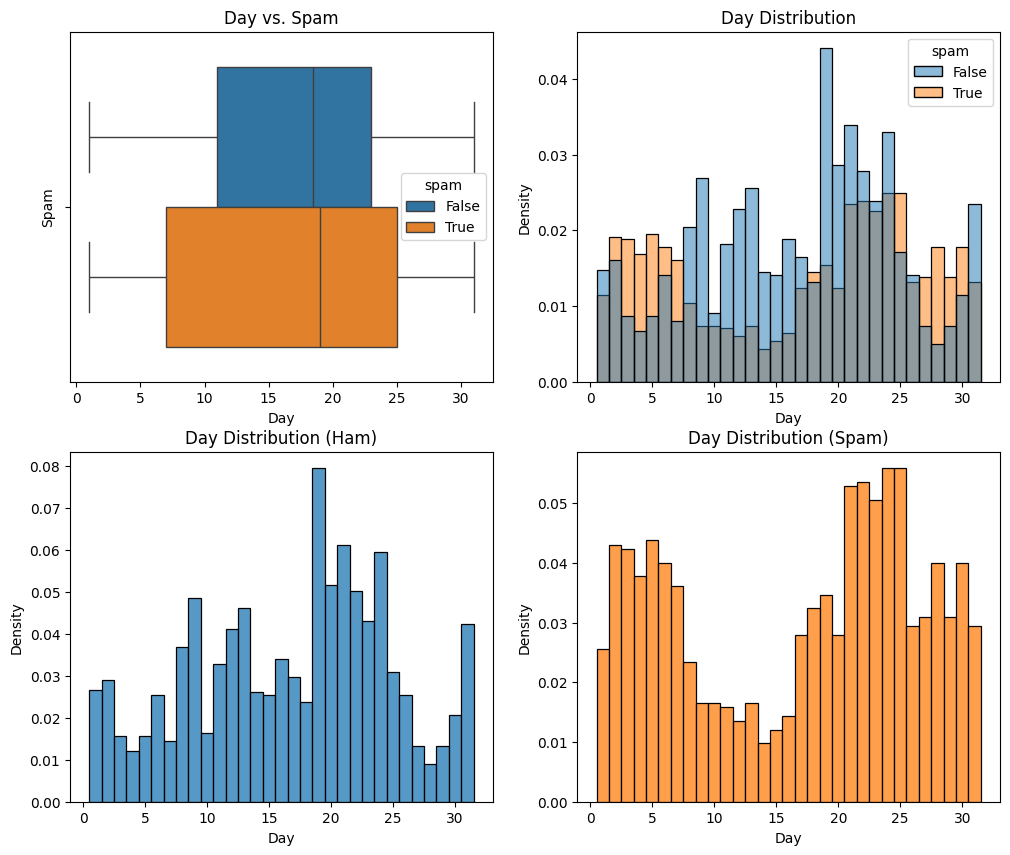

In [225]:
# Day
plot_discrete('day', 'Day')

When we look at the Day feature, we can see that ham emails do not particularly follow any 
distribution. However spam follows a bimodal distribution, with more spam being sent at the end or
beginning of the month.

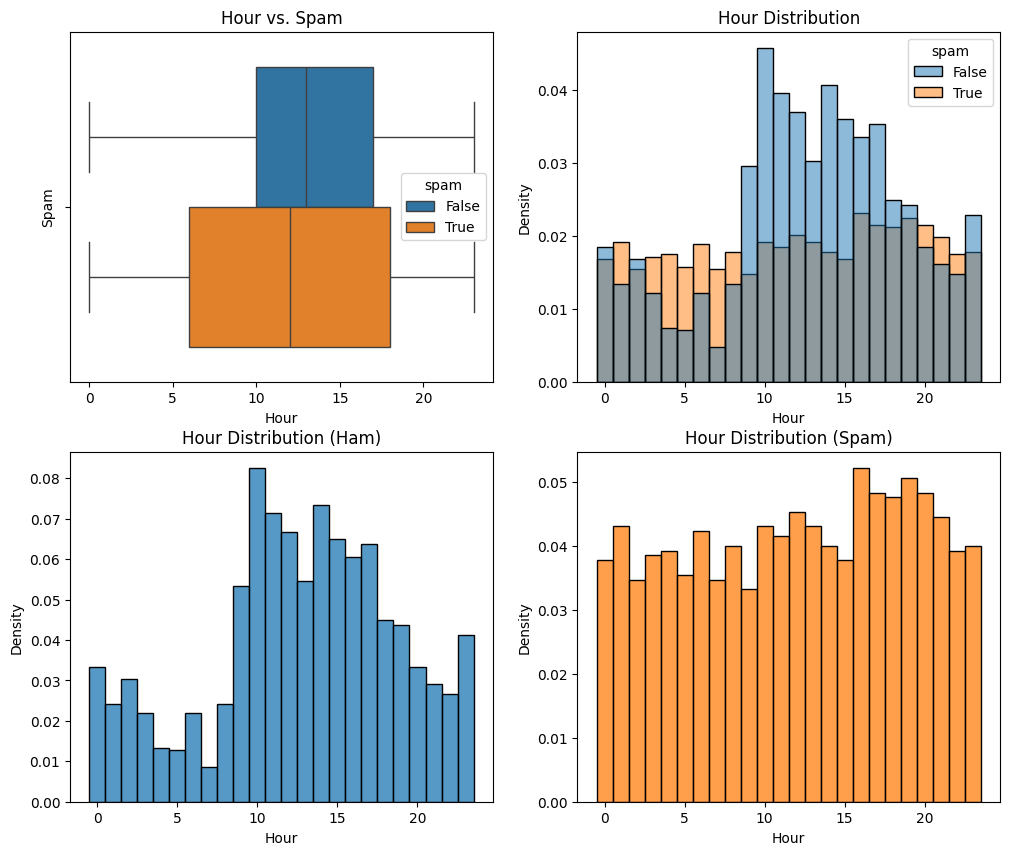

In [226]:
# Hour
plot_discrete('hour', 'Hour')

On first glance, the distributions seem very similar. Yet, when comparing the two distributions, it 
becomes clear that spam is sent at all times of the day with a uniform distribution. Yet ham is 
sent much more often at 10:00-16:00, with little ham being sent in the beginning of the day.